# Train + Validate + Calibrate

Uses the modular pipeline (DataModule → Model → Trainer). Edit overrides to swap models/augs/hparams/W&B.


In [39]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [40]:
# Choose device manually ("cpu" or "cuda"); set to None to auto-detect
DEVICE_OVERRIDE = None  # e.g., "cpu" to force CPU, "cuda" to force GPU if available

In [41]:
from pathlib import Path
from datetime import datetime

RUNS_ROOT = Path('../training_runs')
RUNS_ROOT.mkdir(exist_ok=True)

# Optional manual override for experiment naming
EXPERIMENT_NAME = 'resnet18_resampled_dataset'  # e.g., 'experiment_resnet18_20240520-1530'


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot theming
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300, 'axes.titlesize': 12, 'axes.labelsize': 11, 'legend.fontsize': 10})

PLOTS_DIR = None  # will be set after the config cell

def save_fig(fig, name: str, prefix: str = 'train'):
    assert PLOTS_DIR is not None, 'PLOTS_DIR not set; run the config cell first.'
    path = PLOTS_DIR / f'{prefix}_{name}.pdf'
    fig.savefig(path, bbox_inches='tight', format='pdf')
    print(f'Saved figure to {path}')
    return path


In [43]:
from pathlib import Path
from config import TrainConfig, build_config_from_dict
from training import Trainer
from datetime import datetime
import json

overrides = {
    "data_root": str(Path("../data_resampled")),
    "checkpoints_dir": str(Path("../artifacts/checkpoints")),
    "epochs": 20,
    "wandb_mode": "disabled",  # set to 'online' to log to W&B
    "tensorboard": False,  # set True to log TensorBoard summaries to tensorboard_dir
    "progress_bar": True,
    # "model_name": "efficientnet_b0",
    # "horizontal_flip": 0.5,
    # "max_rotation": 15,
}

cfg = build_config_from_dict(overrides)
if DEVICE_OVERRIDE:
    cfg.device_override = DEVICE_OVERRIDE  # Trainer will respect this attr if set

# Finalize experiment folder
model_tag = cfg.model_name.replace('/', '-')
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
exp_name = EXPERIMENT_NAME or f"experiment_{model_tag}_{timestamp}"
RUN_DIR = RUNS_ROOT / exp_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = RUN_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = RUN_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

cfg.checkpoints_dir = str(ARTIFACTS_DIR / "checkpoints")
cfg.tensorboard_dir = str(ARTIFACTS_DIR / "tensorboard")

CONFIG_PATH = RUN_DIR / "config.json"
with open(CONFIG_PATH, "w") as f:
    json.dump(cfg.to_dict(), f, indent=2)

cfg


TrainConfig(data_root='../data_resampled', batch_size=64, num_workers=4, image_size=256, mean=(0.43, 0.411, 0.374), std=(0.218, 0.207, 0.203), horizontal_flip=0.5, max_rotation=15.0, color_jitter=(0.15, 0.15, 0.15, 0.05), balance_strategy='weighted_sampler', model_name='resnet18', pretrained=True, num_classes=2, dropout=0.1, in_channels=3, freeze_backbone=False, optimizer='adamw', lr=0.0003, weight_decay=0.0001, betas=(0.9, 0.999), momentum=0.9, epochs=20, label_smoothing=0.05, amp=True, grad_clip_norm=1.0, early_stopping=5, checkpoint_metric='macro_f1', progress_bar=True, threshold=0.5, reliability_bins=15, apply_temperature=True, checkpoints_dir='../training_runs/resnet18_resampled_dataset/artifacts/checkpoints', wandb_mode='disabled', wandb_project='hurricane-damage', wandb_entity=None, wandb_run_name=None, wandb_tags=[], tensorboard=False, tensorboard_dir='../training_runs/resnet18_resampled_dataset/artifacts/tensorboard', seed=42)

In [44]:
trainer = Trainer(cfg)
train_summary = trainer.fit()
test_metrics = trainer.test()

# Persist run metadata for later comparison
with open(RUN_DIR / "train_summary.json", "w") as f:
    json.dump(train_summary, f, indent=2)
with open(RUN_DIR / "test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print(f"Saved train summary to {RUN_DIR / 'train_summary.json'}")
print(f"Saved test metrics to {RUN_DIR / 'test_metrics.json'}")
train_summary, test_metrics


Epoch 1/20:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 11:41:16,062 | INFO | Epoch 000 | train_loss=0.2030 | val_loss=0.2222 | val_f1=0.952


Epoch 2/20:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 11:41:35,371 | INFO | Epoch 001 | train_loss=0.1562 | val_loss=0.1422 | val_f1=0.990


Epoch 3/20:   0%|          | 0/296 [00:00<?, ?it/s]

...

2025-12-06 11:45:58,430 | INFO | Epoch 015 | train_loss=0.1183 | val_loss=0.1203 | val_f1=0.998


Epoch 17/20:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 11:46:17,785 | INFO | Epoch 016 | train_loss=0.1181 | val_loss=0.1196 | val_f1=0.999
2025-12-06 11:46:17,786 | INFO | Early stopping.


Saved train summary to ../training_runs/resnet18_resampled_dataset/train_summary.json
Saved test metrics to ../training_runs/resnet18_resampled_dataset/test_metrics.json


({'history': [{'epoch': 0,
    'train_loss': 0.203044649314236,
    'val_loss': 0.22219210863113403,
    'val/accuracy': 0.9550224887556222,
    'val/macro_precision': 0.9447060555931523,
    'val/macro_recall': 0.9628160119992175,
    'val/macro_f1': 0.9521158472642033,
    'val/brier': 0.03625642050993246,
    'val/ece': 0.02356498858620086,
    'lr': 0.00029815940691897306},
   {'epoch': 1,
    'train_loss': 0.15616300223848303,
    'val_loss': 0.1422094702720642,
    'val/accuracy': 0.9905047476261869,
    'val/macro_precision': 0.9878468178171183,
    'val/macro_recall': 0.9916793469991088,
    'val/macro_f1': 0.9897103141792731,
    'val/brier': 0.009138719759771017,
    'val/ece': 0.02286156134746005,
    'lr': 0.0002926829491861254},
   {'epoch': 2,
    'train_loss': 0.14441929445476145,
    'val_loss': 0.1455555260181427,
    'val/accuracy': 0.9885057471264368,
    'val/macro_precision': 0.9851744698981326,
    'val/macro_recall': 0.9901229267656457,
    'val/macro_f1': 0.9875

,epoch,train_loss,val_loss,val/accuracy,val/macro_precision,val/macro_recall,val/macro_f1,val/brier,val/ece,lr
0,0,0.203045,0.222192,0.955022,0.944706,0.962816,0.952116,0.036256,0.023565,0.000298
1,1,0.156163,0.142209,0.990505,0.987847,0.991679,0.989710,0.009139,0.022862,0.000293
2,2,0.144419,0.145556,0.988506,0.985174,0.990123,0.987559,0.009969,0.022699,0.000284
3,3,0.138008,0.132309,0.993503,0.991911,0.994014,0.992947,0.005217,0.020345,0.000271
4,4,0.135321,0.139664,0.988506,0.984438,0.991051,0.987581,0.009069,0.024621,0.000256
5,5,0.128609,0.124906,0.996502,0.996042,0.996349,0.996195,0.003214,0.027240,0.000238
6,6,0.130170,0.139660,0.990005,0.987440,0.990981,0.989165,0.008415,0.025658,0.000218
7,7,0.126006,0.133262,0.993003,0.990411,0.994553,0.992420,0.006447,0.027670,0.000197
8,8,0.125894,0.122319,0.999000,0.998913,0.998913,0.998913,0.002502,0.029414,0.000174
9,9,0.124296,0.121551,0.998501,0.998523,0.998214,0.998368,0.001923,0.023995,0.000150


Saved figure to ../training_runs/resnet18_resampled_dataset/plots/train_loss_curves.pdf


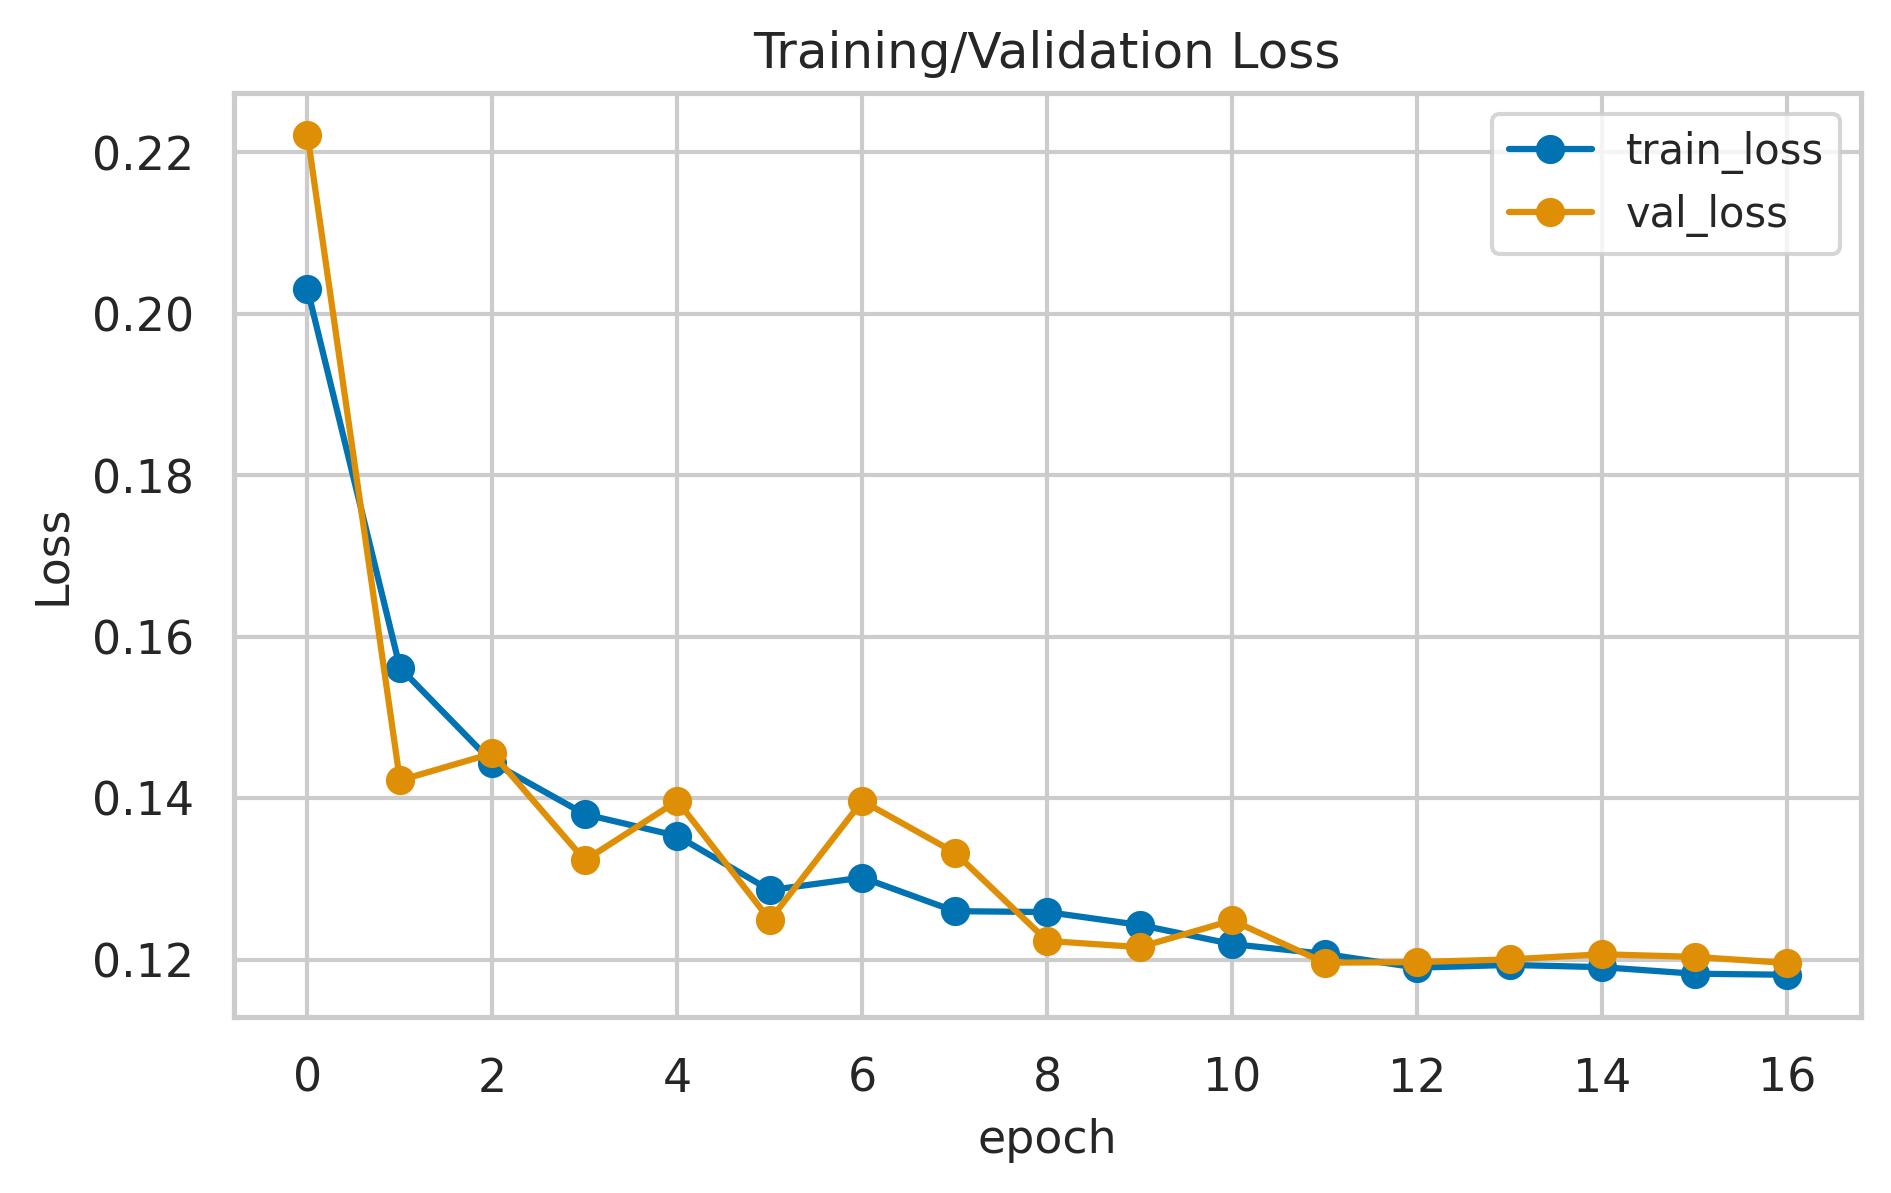

Saved figure to ../training_runs/resnet18_resampled_dataset/plots/train_val_metrics.pdf


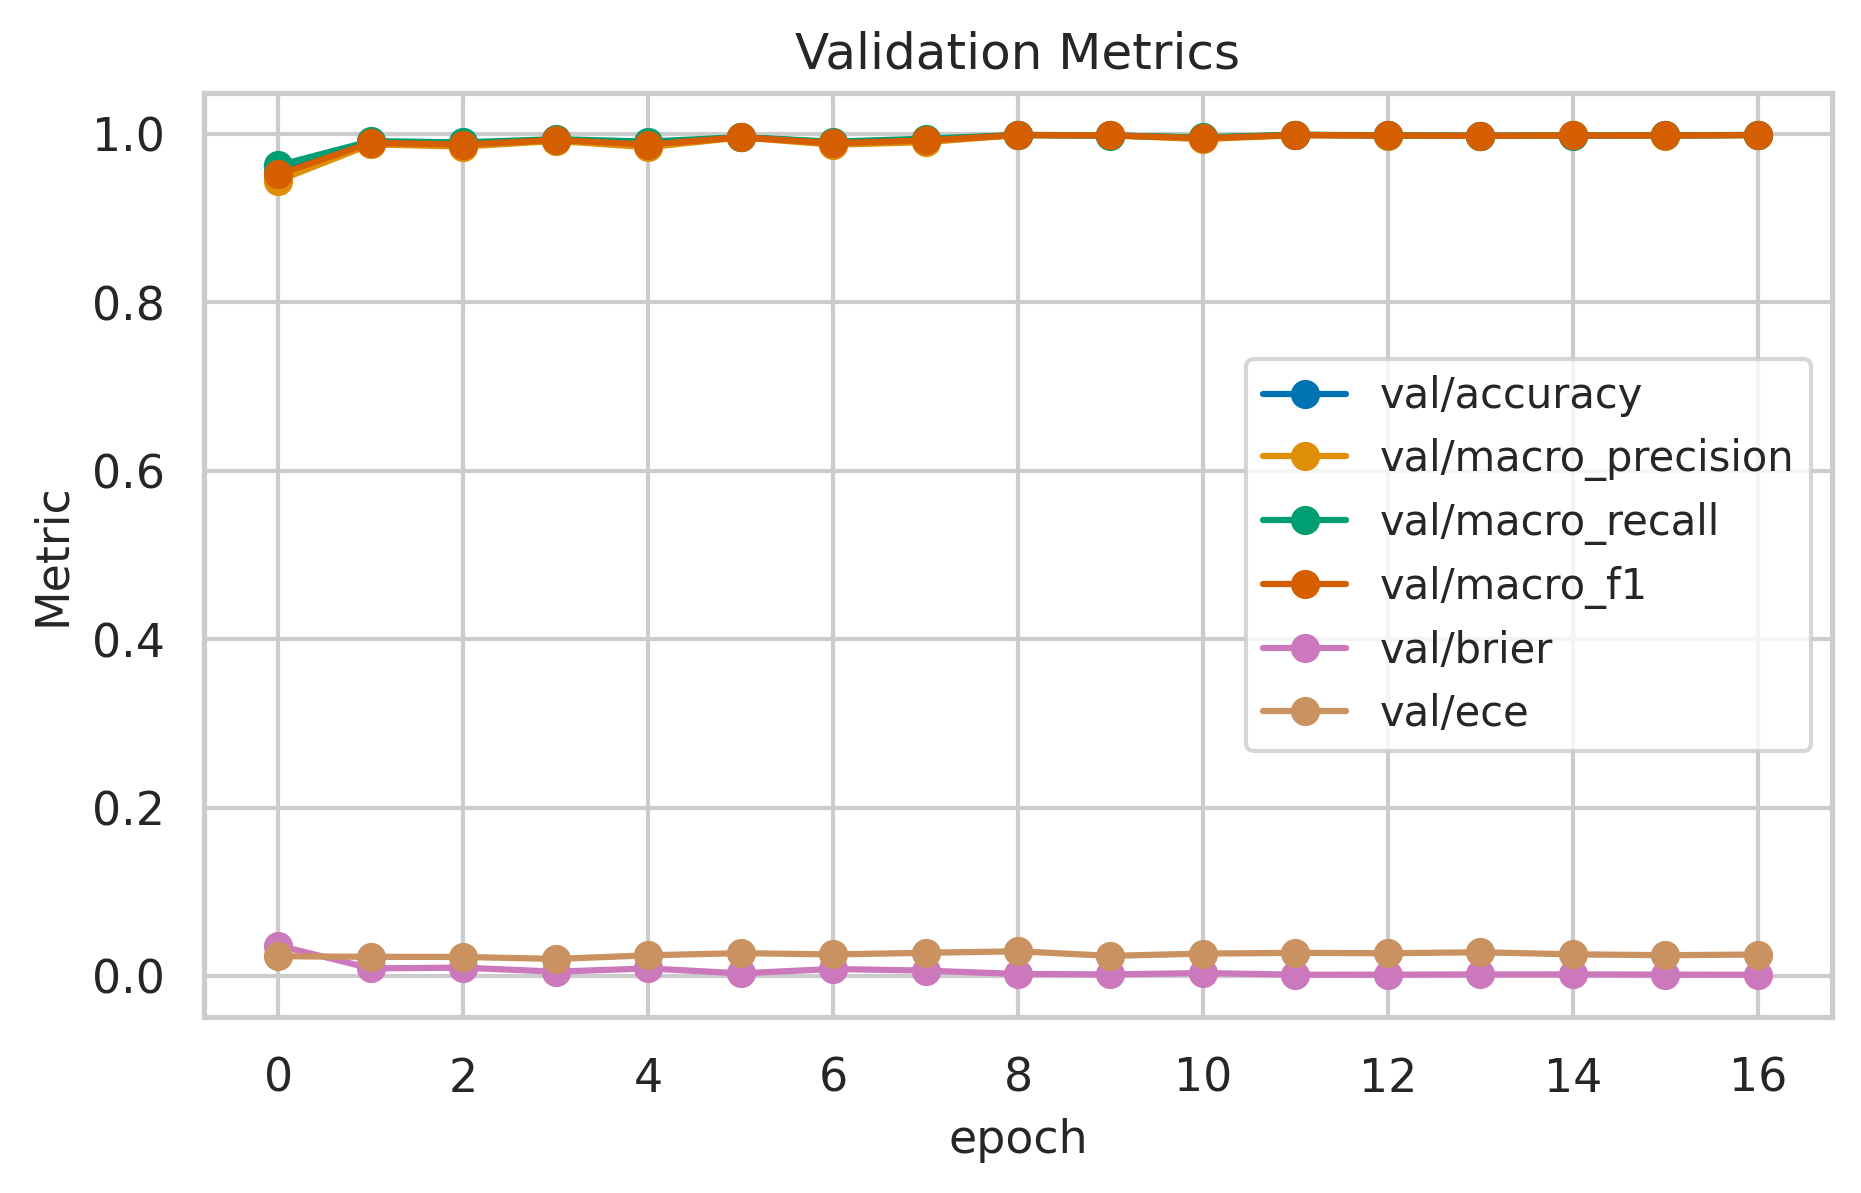

Saved figure to ../training_runs/resnet18_resampled_dataset/plots/train_confusion.pdf


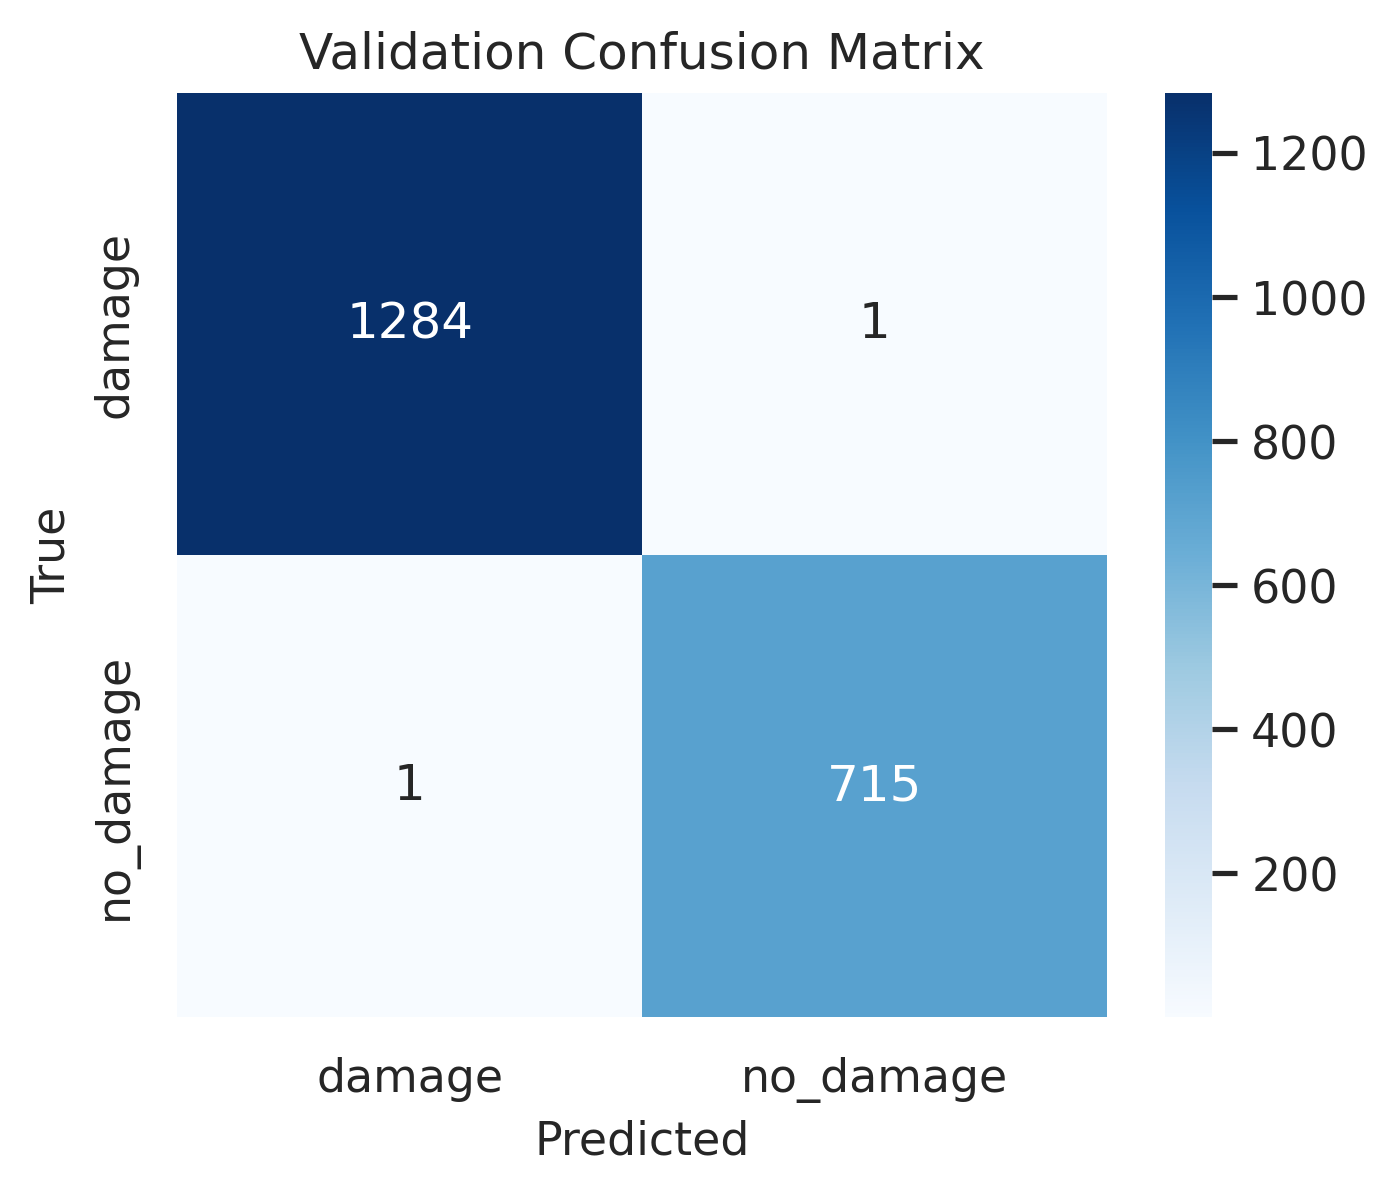

Saved figure to ../training_runs/resnet18_resampled_dataset/plots/train_score_hist.pdf


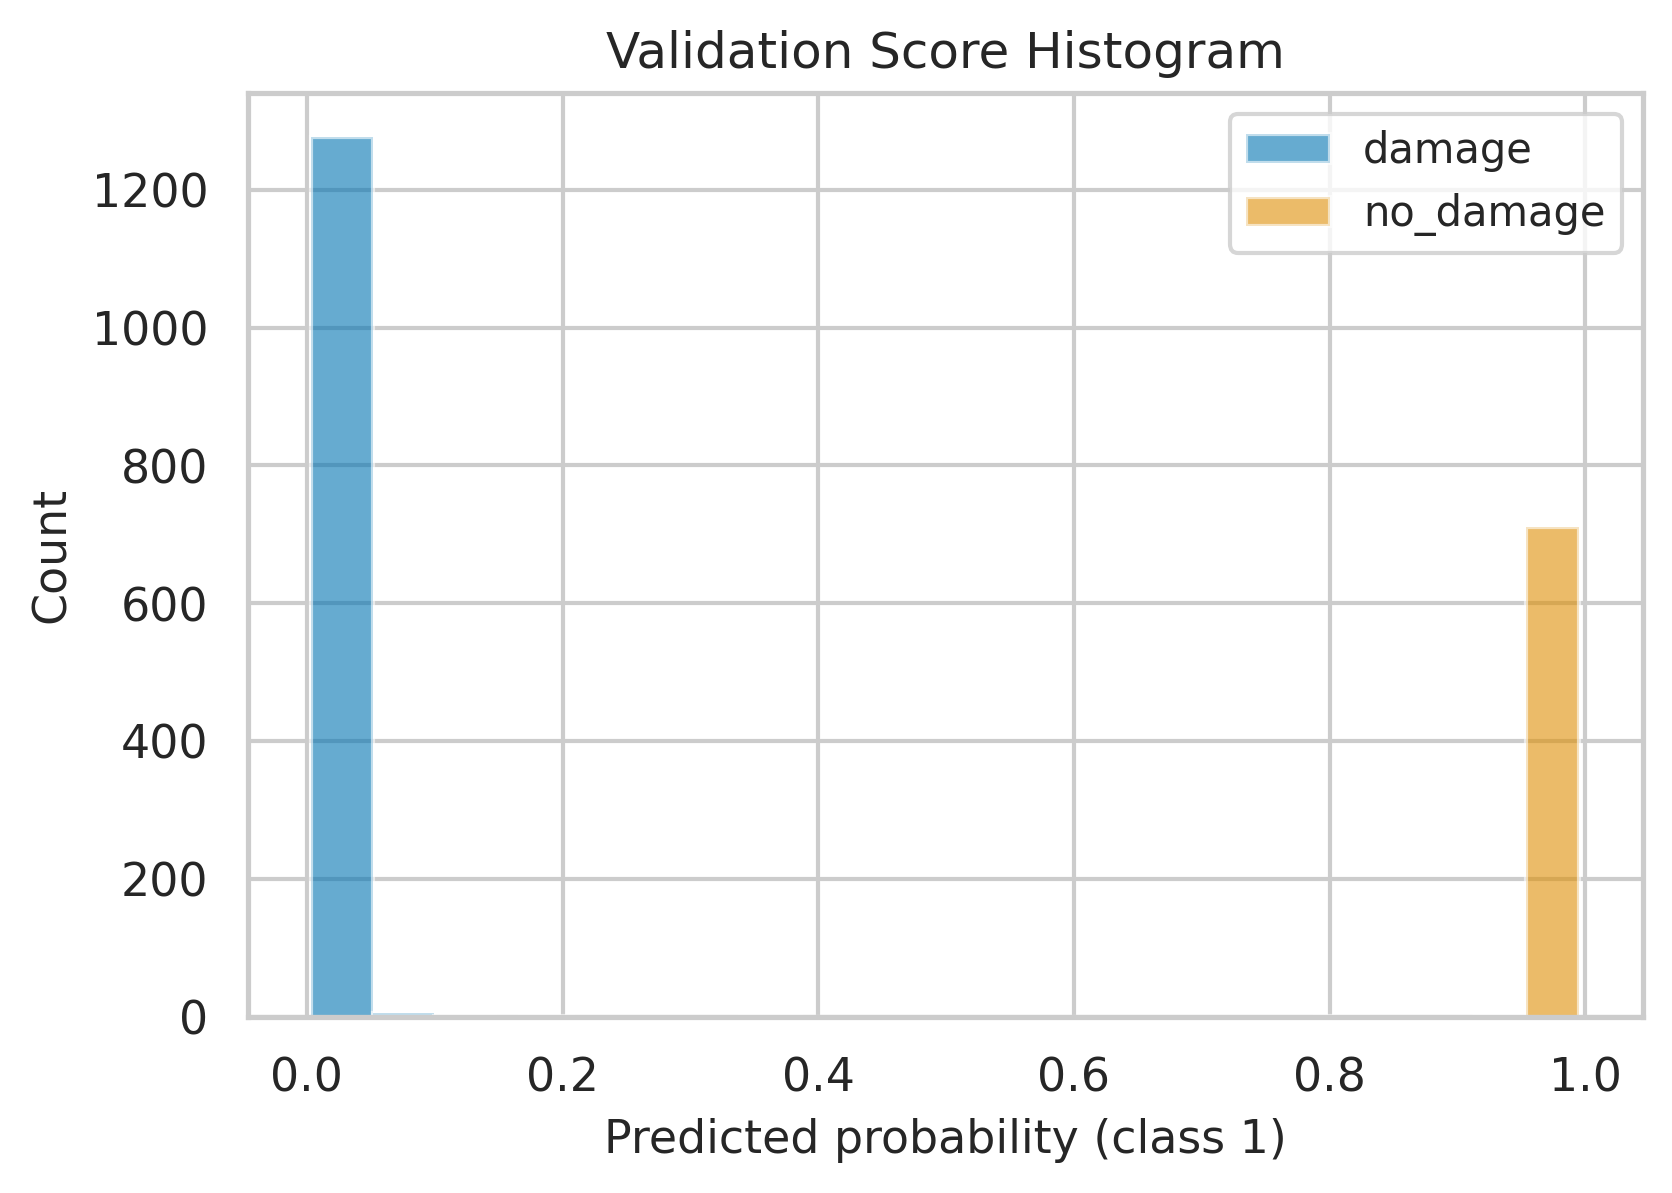

Saved figure to ../training_runs/resnet18_resampled_dataset/plots/train_reliability.pdf


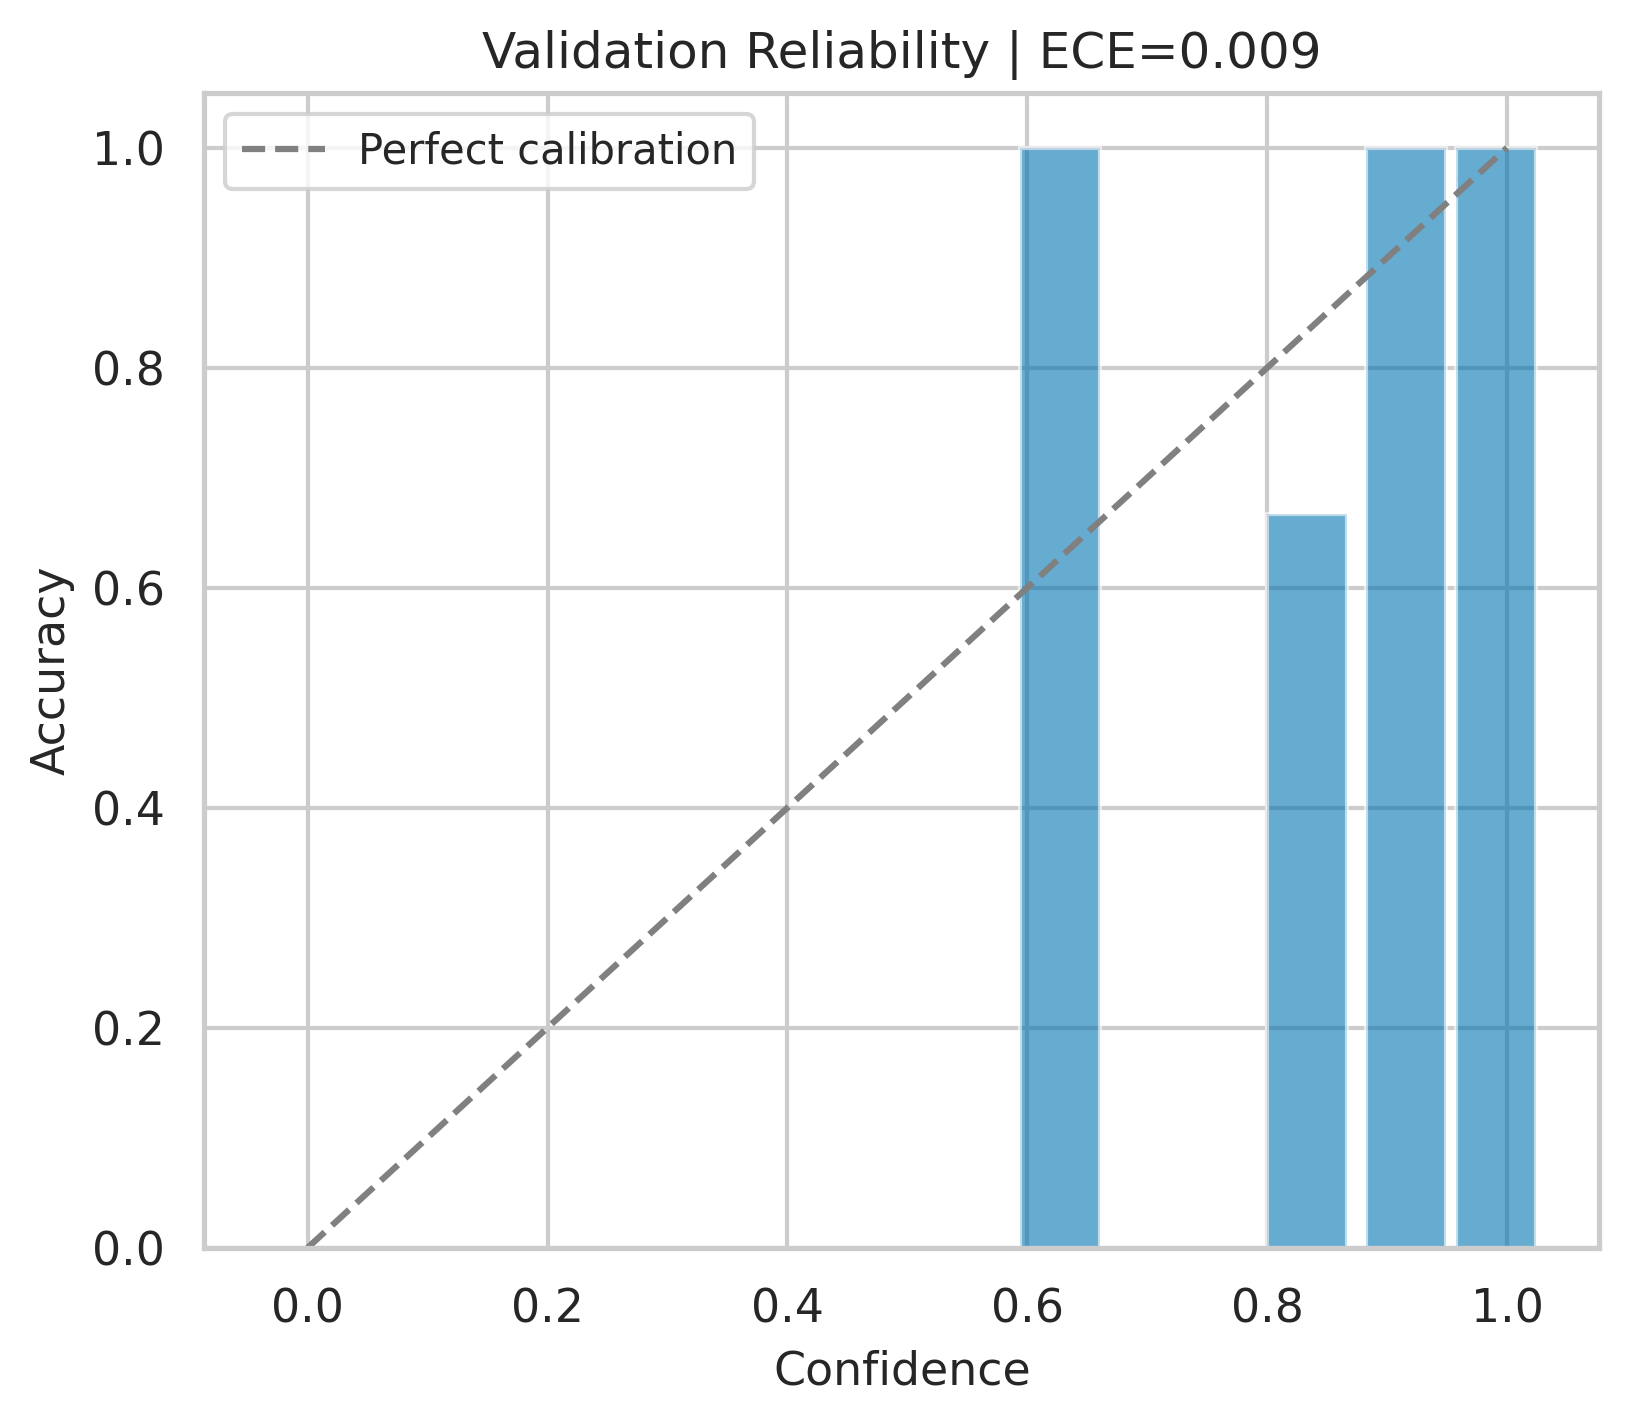

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from validation import evaluate, reliability_bins

history_df = pd.DataFrame(train_summary["history"])
display(history_df)

# Loss curves
fig, ax = plt.subplots(figsize=(7, 4))
history_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", ax=ax)
ax.set_ylabel("Loss")
ax.set_title("Training/Validation Loss")
save_fig(fig, "loss_curves")
plt.show()

# Validation metrics over epochs
metric_cols = [col for col in history_df.columns if col.startswith("val/") and col not in ("val/loss",)]
if metric_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    history_df.plot(x="epoch", y=metric_cols, marker="o", ax=ax)
    ax.set_ylabel("Metric")
    ax.set_title("Validation Metrics")
    save_fig(fig, "val_metrics")
    plt.show()

# Evaluate on validation for detailed plots
val_metrics, val_outputs = evaluate(
    trainer.model,
    trainer.val_loader,
    trainer.device,
    trainer.cfg,
    temperature=getattr(trainer, "temperature", None),
)

val_probs = val_outputs["probs"]
val_labels = val_outputs["labels"].cpu().numpy()
val_preds = val_probs.argmax(axis=1)
class_names = trainer.datamodule.train_dataset.classes

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Validation Confusion Matrix")
save_fig(fig, "confusion")
plt.show()

# Score histogram for positive class
pos_scores = val_probs[:, 1] if val_probs.shape[1] > 1 else val_probs[:, 0]
fig, ax = plt.subplots(figsize=(6, 4))
for label_val, label_name in enumerate(class_names):
    ax.hist(pos_scores[val_labels == label_val], bins=20, alpha=0.6, label=label_name)
ax.set_xlabel("Predicted probability (class 1)")
ax.set_ylabel("Count")
ax.set_title("Validation Score Histogram")
ax.legend()
save_fig(fig, "score_hist")
plt.show()

# Reliability diagram
bin_conf, bin_acc, bin_count = reliability_bins(
    val_probs, val_labels, n_bins=trainer.cfg.reliability_bins
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_conf, bin_acc, width=1.0 / trainer.cfg.reliability_bins, alpha=0.6, align="center")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title(f"Validation Reliability | ECE={val_metrics['ece']:.3f}")
ax.legend()
save_fig(fig, "reliability")
plt.show()